In [2]:
import numpy as np
import pandas as pd
import os
from os import path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import RadiusNeighborsRegressor, KNeighborsRegressor
data_loc = '/project/wyin/jlee/ml-project/data-collection/full-dataset/data'
print(os.getcwd())

/project/wyin/jlee/ml-project/dos-prediction


In [3]:
train_set = np.load('data/train-set.npz')
train_params = train_set['params']
train_dos = train_set['dos']

In [4]:
val_set = np.load('data/val-set.npz')
val_params = val_set['params']
val_dos = val_set['dos']

In [5]:
test_set = np.load('data/test-set.npz')
test_params = test_set['params']
test_dos = test_set['dos']

In [6]:
scaler = StandardScaler()
train_params_scaled = scaler.fit_transform(train_params)
val_params_scaled = scaler.transform(val_params)

In [7]:
knn_mse_uniform = []
for i in range(1, 20):
    print(f"trying n neights = {i}")
    neigh = KNeighborsRegressor(n_neighbors = i)
    neigh.fit(train_params_scaled, train_dos)
    predicted = neigh.predict(val_params_scaled)
    
    mse = np.mean((val_dos - predicted)**2)
    knn_mse_uniform.append(mse)

knn_mse_uniform = np.array(knn_mse_uniform)

trying n neights = 1
trying n neights = 2
trying n neights = 3
trying n neights = 4
trying n neights = 5
trying n neights = 6
trying n neights = 7
trying n neights = 8
trying n neights = 9
trying n neights = 10
trying n neights = 11
trying n neights = 12
trying n neights = 13
trying n neights = 14
trying n neights = 15
trying n neights = 16
trying n neights = 17
trying n neights = 18
trying n neights = 19


5.1602937422550505e-05
4


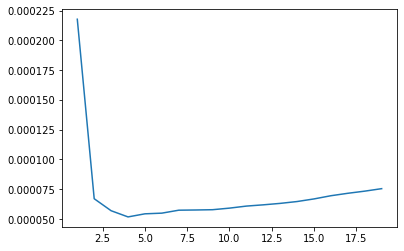

In [8]:
plt.plot(np.arange(1, 20), knn_mse_uniform)
print(np.min(knn_mse_uniform))
print(np.argmin(knn_mse_uniform) + 1)

In [9]:
knn_mse_weighted = []
for i in range(1, 20):
    print(f'trying n neighs = {i}')
    neigh = KNeighborsRegressor(n_neighbors = i, weights = 'distance')
    neigh.fit(train_params_scaled, train_dos)
    predicted = neigh.predict(val_params_scaled)
    
    mse = np.mean((val_dos - predicted)**2)
    knn_mse_weighted.append(mse)

knn_mse_weighted = np.array(knn_mse_weighted)

trying n neighs = 1
trying n neighs = 2
trying n neighs = 3
trying n neighs = 4
trying n neighs = 5
trying n neighs = 6
trying n neighs = 7
trying n neighs = 8
trying n neighs = 9
trying n neighs = 10
trying n neighs = 11
trying n neighs = 12
trying n neighs = 13
trying n neighs = 14
trying n neighs = 15
trying n neighs = 16
trying n neighs = 17
trying n neighs = 18
trying n neighs = 19


5.097274342037843e-05
4


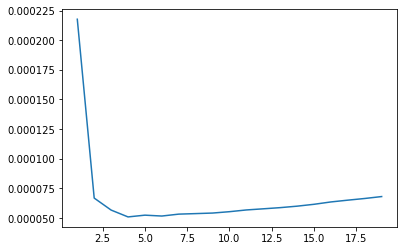

In [10]:
plt.plot(np.arange(1, 20), knn_mse_weighted)
print(np.min(knn_mse_weighted))
print(np.argmin(knn_mse_weighted) + 1)

In [11]:
test_params_scaled = scaler.transform(test_params)

neigh = KNeighborsRegressor(n_neighbors = 4, weights = 'distance')
neigh.fit(train_params_scaled, train_dos)
predicted = neigh.predict(test_params_scaled)

mse = np.mean((test_dos - predicted)**2)
mae = np.mean(np.abs(test_dos - predicted))
print(f"Testing data mse: {mse}")
print(f"Testing data mae: {mae}")

Testing data mse: 4.80901913711635e-05
Testing data mae: 0.0014842881938328964
